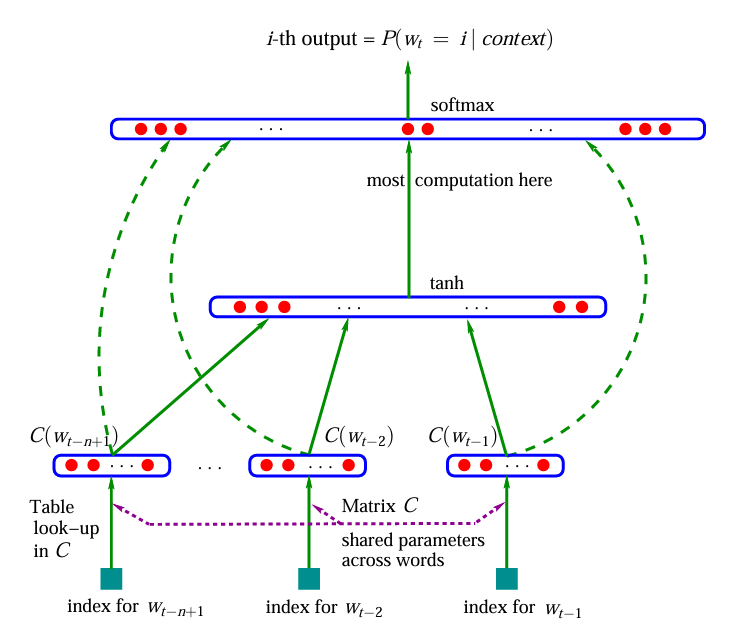

In [1]:
zhs = open('data/names1/names1.txt','r').read().splitlines()
pinyins = open('data/names1/names1_pinyin_components.txt','r').read().splitlines()
pinyins_to_chars = open('data/names1/pinyin_components_to_hanzi_chars1.txt','r').read().splitlines()

i=0
for zh,p,ch in zip(zhs[:10],pinyins[:10],pinyins_to_chars[:10]):
    print(f'{i:02d}: {zh:5} {p:25} {ch}')
    i+=1

len(zhs),len(pinyins),len(pinyins_to_chars)

00: 倪|子宁  n i | z i n ing           n i	倪
01: 宋|云深  s ong | y un sh en        z i	子
02: 尤|听澜  y ou | t ing l an         n ing	宁
03: 唐|承安  t ang | ch eng _ an       s ong	宋
04: 龙|长宁  l ong | zh ang n ing      y un	云 韵
05: 田|清玄  t ian | q ing x uan       sh en	深 沈 申
06: 柯|川   k e | ch uan              y ou	尤 游
07: 郑|灵微  zh eng | l ing w ei       t ing	听
08: 任|瑶音  r en | y ao y in          l an	澜 岚 兰
09: 汪|音   w ang | y in              t ang	唐 棠 汤


(12000, 12000, 188)

In [2]:
# set(''.join(pinyins))
tokens = [p.split() for p in pinyins]
token_list = sorted({'.'} | {t for token in tokens for t in token})
token_list_len = len(token_list)

stoi = {s:i for i,s in enumerate(token_list)}
itos = {i:s for i,s in enumerate(token_list)}


print(pinyins[:2])
print(tokens[:2])
print(sorted(set([t for token in tokens[:2] for t in token])))

print(itos)
print(stoi)
print(token_list_len)

['n i | z i n ing', 's ong | y un sh en']
[['n', 'i', '|', 'z', 'i', 'n', 'ing'], ['s', 'ong', '|', 'y', 'un', 'sh', 'en']]
['en', 'i', 'ing', 'n', 'ong', 's', 'sh', 'un', 'y', 'z', '|']
{0: '.', 1: '_', 2: 'a', 3: 'ai', 4: 'an', 5: 'ang', 6: 'ao', 7: 'b', 8: 'c', 9: 'ch', 10: 'd', 11: 'e', 12: 'ei', 13: 'en', 14: 'eng', 15: 'f', 16: 'g', 17: 'h', 18: 'i', 19: 'ia', 20: 'ian', 21: 'iang', 22: 'iao', 23: 'ie', 24: 'in', 25: 'ing', 26: 'iong', 27: 'iu', 28: 'j', 29: 'k', 30: 'l', 31: 'm', 32: 'n', 33: 'o', 34: 'ong', 35: 'ou', 36: 'p', 37: 'q', 38: 'r', 39: 's', 40: 'sh', 41: 't', 42: 'u', 43: 'ua', 44: 'uai', 45: 'uan', 46: 'uang', 47: 'ue', 48: 'ui', 49: 'un', 50: 'uo', 51: 'v', 52: 'w', 53: 'x', 54: 'y', 55: 'z', 56: 'zh', 57: '|'}
{'.': 0, '_': 1, 'a': 2, 'ai': 3, 'an': 4, 'ang': 5, 'ao': 6, 'b': 7, 'c': 8, 'ch': 9, 'd': 10, 'e': 11, 'ei': 12, 'en': 13, 'eng': 14, 'f': 15, 'g': 16, 'h': 17, 'i': 18, 'ia': 19, 'ian': 20, 'iang': 21, 'iao': 22, 'ie': 23, 'in': 24, 'ing': 25, 'iong': 26

In [3]:
# 训练集 80% -> 优化模型权重
# 验证集 10% -> 调整超参数
# 测试集 10% -> 测试模型泛化性和准确率
import torch
import torch.nn.functional as F

block_size = 3 # 上下文长度
def build_dataset(data):
    X,Y = [],[]
    for t in data:
        # print(['.']*block_size + t + ['.'])
        # print(t + ['.'])

        str1 = ['.']*block_size + t + ['.']
        str2 = t + ['.']

        i=0
        for _,y in zip(str1,str2):
            # print(str1[i:i+block_size],y)
            # print([stoi[str1[j]] for j in range(i,i+block_size)],stoi[y])
            X.append([stoi[str1[j]] for j in range(i,i+block_size)])
            Y.append(stoi[y])
            i+=1


    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape,Y.shape,X.dtype,Y.dtype)
    return X,Y

import random
random.seed(0)
random.shuffle(tokens)
n1 = int(0.8*len(tokens))
n2 = int(0.9*len(tokens))

Xtr,Ytr   = build_dataset(tokens[:n1])
Xdev,Ydev = build_dataset(tokens[n1:n2])
Xte,Yte   = build_dataset(tokens[n2:])

torch.Size([74388, 3]) torch.Size([74388]) torch.int64 torch.int64
torch.Size([9262, 3]) torch.Size([9262]) torch.int64 torch.int64
torch.Size([9266, 3]) torch.Size([9266]) torch.int64 torch.int64


In [4]:
embedding_dim = 2
hidden_dim = 100
batch_size = 32

g = torch.Generator().manual_seed(0)
E = torch.randn((token_list_len, embedding_dim)        ,generator=g)
W1 = torch.randn((block_size*embedding_dim, hidden_dim),generator=g) * 0.4
b1 = torch.randn(hidden_dim                            ,generator=g) * 0.2
W2 = torch.randn((hidden_dim,token_list_len)           ,generator=g) * 0.01
b2 = torch.randn(token_list_len                        ,generator=g) * 0

parameters=[E,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad = True
lr_base = 0.3

100


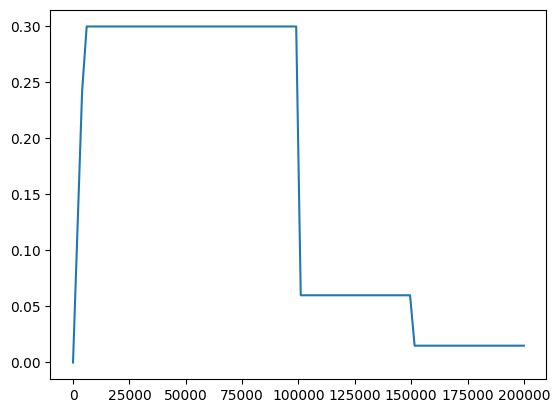

In [5]:
# 1.
def get_lr1(lr_base,i,max_steps):
    if i<max_steps/2:
        return lr_base
    if i>max_steps-max_steps/4:
        return lr_base/100
    return lr_base/10

# 2.
import math

def get_lr2(lr_base, i, max_steps, warmup_steps=10000, lr_min=1e-5):
    """
    余弦退火学习率
    warmup_steps: 预热步数，前1万步线性增加
    lr_min: 最低学习率，防止后期完全不动
    """
    # 1. 预热阶段：从 0 线性增加到 lr_base
    if i < warmup_steps:
        return lr_base * (i / warmup_steps)
    
    # 2. 余弦退火阶段：从 lr_base 平滑衰减到 lr_min
    # 注意要减去预热步数
    progress = (i - warmup_steps) / (max_steps - warmup_steps)
    # 使用 cosine 公式
    return lr_min + 0.5 * (lr_base - lr_min) * (1.0 + math.cos(math.pi * progress))


def get_lr3(lr_base, i, max_steps, warmup_steps=10000, lr_min=1e-5):
    """
    线性预热 + 线性衰减
    """
    if i < warmup_steps:
        return lr_base * (i / warmup_steps)
    
    # 计算剩余步数的比例
    decay_ratio = (max_steps - i) / (max_steps - warmup_steps)
    return lr_min + (lr_base - lr_min) * decay_ratio

def get_lr4(lr_base, i, max_steps, warmup_steps=5000):
    # 增加预热
    if i < warmup_steps:
        return lr_base * (i / warmup_steps)
        
    if i < max_steps / 2:
        return lr_base
    if i > max_steps - max_steps / 4:
        return lr_base / 20  # 原来是 /100，现在改成 /20，最后一阶段不至于学不动
    return lr_base / 5       # 原来是 /10，现在改成 /5


import matplotlib.pyplot as plt
%matplotlib inline

get_lr = get_lr4
xs = torch.linspace(0,200000,100).numpy()
print(len(xs))
plt.plot(xs,[get_lr(0.3,x,200000) for x in xs])


In [6]:
# train
max_steps = 200000
stepi = []
lossi = []
for i in range(max_steps):
    # forward pass
    batch_idxs = torch.randint(0,Xtr.shape[0],(batch_size,))
    emb = E[Xtr[batch_idxs]]
    hpreact = emb.view(-1,block_size*embedding_dim)@W1+b1
    h = torch.tanh(hpreact)
    logits = h@W2+b2
    loss = F.cross_entropy(logits,Ytr[batch_idxs])

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = get_lr(lr_base,i,max_steps)
    for p in parameters:
        p.data += -lr*p.grad
    
    # track stats
    stepi.append(i)
    lossi.append(loss.item())

    # print
    if(i%10000==0):
        print(f'{i:6d}/{max_steps:6d}: loss={loss.item()}')
    #break


     0/200000: loss=4.076566696166992
 10000/200000: loss=1.3509809970855713
 20000/200000: loss=1.6061264276504517
 30000/200000: loss=0.9841488599777222
 40000/200000: loss=1.530341386795044
 50000/200000: loss=1.2464200258255005
 60000/200000: loss=1.4773725271224976
 70000/200000: loss=1.387071967124939
 80000/200000: loss=1.8158811330795288
 90000/200000: loss=1.544613003730774
100000/200000: loss=1.221006989479065
110000/200000: loss=1.6178096532821655
120000/200000: loss=1.2138400077819824
130000/200000: loss=1.3500514030456543
140000/200000: loss=1.5178465843200684
150000/200000: loss=1.8003195524215698
160000/200000: loss=1.5082205533981323
170000/200000: loss=1.3989826440811157
180000/200000: loss=1.3218580484390259
190000/200000: loss=1.248695969581604


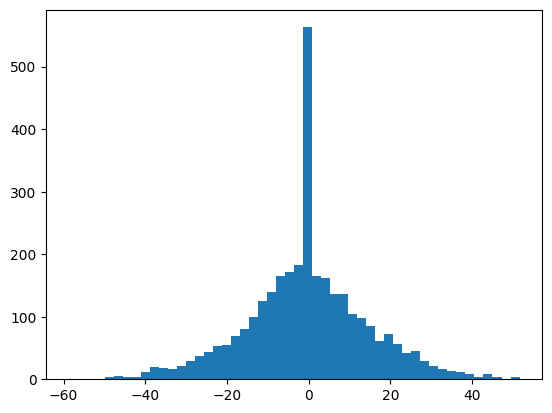

In [7]:
plt.hist(hpreact.view(-1).tolist(),50);

torch.Size([32, 100])


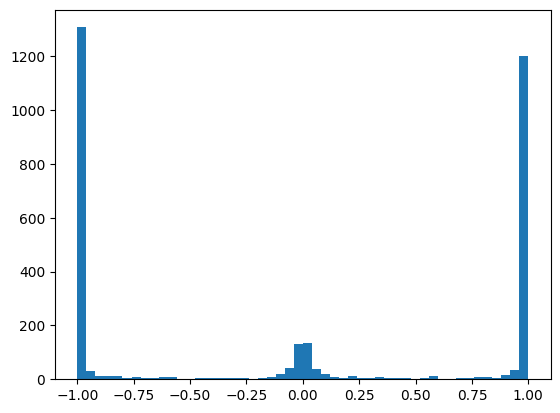

In [8]:
print(h.shape)
plt.hist(h.view(-1).tolist(),50);

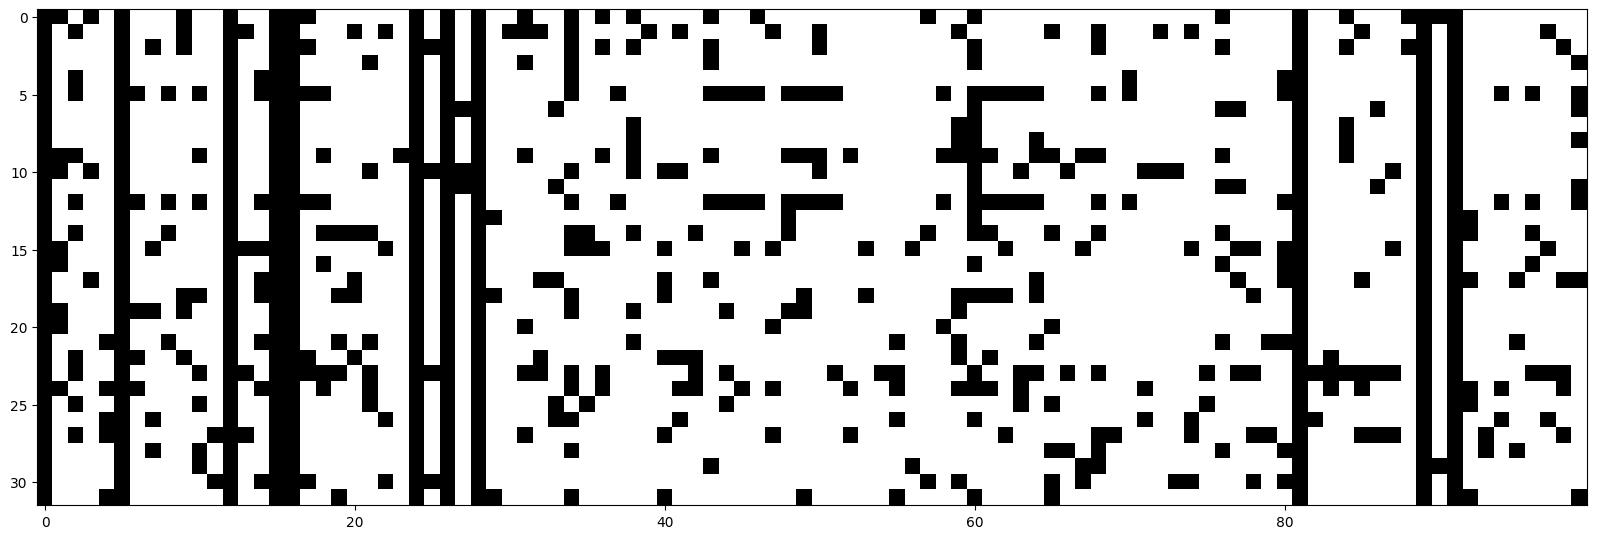

In [9]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap='gray',interpolation='nearest')

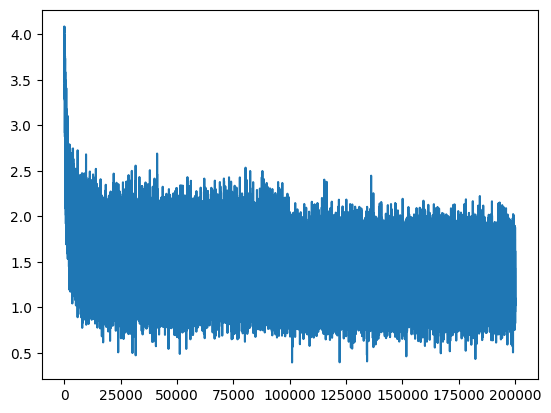

In [10]:
# vailiate
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(stepi,lossi)

In [11]:
@torch.no_grad()
def print_loss(type):
    x,y={
        'train':{Xtr,Ytr},
        'val'  :{Xdev,Ydev},
        'test' :{Xte,Yte}   
    }[type]
    emb = E[x]
    h = torch.tanh(emb.view(-1,block_size*embedding_dim)@W1+b1)
    logits = h@W2+b2
    loss = F.cross_entropy(logits,y)
    print(f'{type:6}: {loss.item()}')

print_loss('train')
print_loss('val')


# train : 1.339411735534668
# val   : 1.3642113208770752

# train : 1.335385799407959
# val   : 1.3554308414459229

# train : 1.3349207639694214
# val   : 1.3573867082595825

# train : 1.3349825143814087
# val   : 1.3612276315689087

train : 1.3394083976745605
val   : 1.3598064184188843


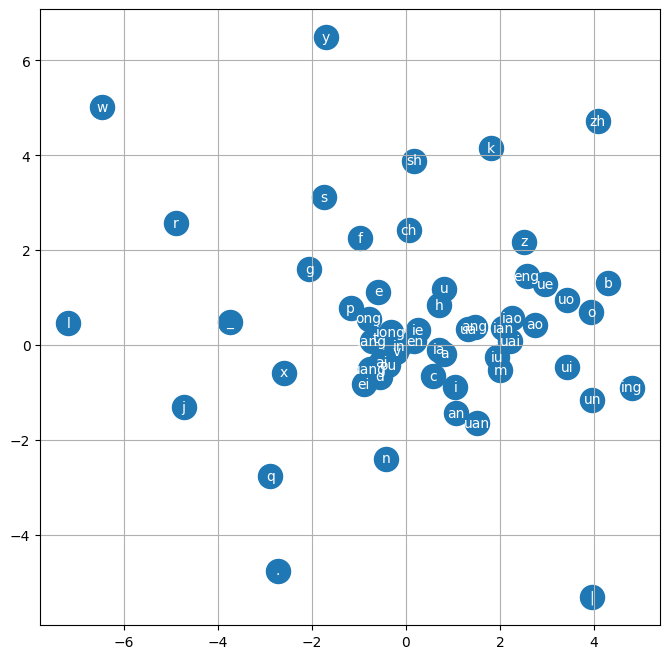

In [12]:
plt.figure(figsize=(8,8))
plt.scatter(E[:,0].data,E[:,1].data,s=300)
for i in range(E.shape[0]):
    plt.text(E[i,0].item(),E[i,1].item(),itos[i],ha='center',va='center',color='white')
plt.grid('minor')

In [13]:
# 采样
g = torch.Generator().manual_seed(0)

samples=[]
names=[]
for i in range(100):
    has_first_name = False
    out = []
    context = [0]*3  #'...'起始
    # print(context)
    while True:
        emb = E[torch.tensor([context])]

        # print(emb)

        h = torch.tanh(emb.view(1,-1)@W1+b1)
        # print(h.shape)
        logits = h@W2+b2
        probs = F.softmax(logits,dim=1)
        # print(probs.shape, probs[0].sum())
        ix = torch.multinomial(probs,num_samples=1,replacement=True,generator=g).item()
        char = itos[ix]
        # 确保每次采样一个姓氏一个名
        if char=='.':
            if has_first_name:
                break
            else:
                continue
        if char=='|':
            if not has_first_name:
                has_first_name = True
            else:
                break 
        context = context[1:]+[ix]       
        out.append(char)
        
        # #小于5个字
        # if len(out)>=4*2 :
        #     break
    samples.append(out)
    

i=0        
for o in samples:
    print(f'{i:03d}:{o}')
    i+=1 

000:['t', 'an', '|', 'zh', 'ang', 'g', 'eng']
001:['sh', 'i', '|', 'm', 'o', 'b', 'ai']
002:['l', 'i', '|', 'x', 'uan', 'h', 'eng']
003:['zh', 'eng', '|', 'h', 'uai', 'n', 'ing']
004:['b', 'ai', '|', 'w', 'an']
005:['d', 'ai', '|', 'q', 'ing', 'q', 'iu']
006:['d', 'uan', '|', 'm', 'ing', 'ch', 'uan']
007:['x', 'ue', '|', 'y', 'an']
008:['j', 'ia', '|', 'y', 'u', 'w', 'en']
009:['m', 'o', '|', 'y', 'an']
010:['t', 'ong', '|', 'x', 'i']
011:['w', 'u', '|', 'z', 'i', 'n', 'ing']
012:['n', 'ie', '|', 'y', 'u', 'h', 'ang']
013:['d', 'ing', '|', 'y', 'ao', 'y', 'ue']
014:['h', 'e', '|', 'q', 'ing', 'l', 'an']
015:['x', 'i', 'm', 'en', '|', 'q', 'ing', 'y', 'an']
016:['y', 'uan', '|', 'y', 'u', 'ch', 'i']
017:['q', 'ian', '|', 'w', 'an']
018:['t', 'ian', '|', 'q', 'ing', 'y', 'uan']
019:['x', 'ue', '|', 'j', 'ing', 'x', 'ing']
020:['l', 'in', '|', 'j', 'ing', 'x', 'ing']
021:['l', 'u', '|', 'zh', 'ang', 'g', 'eng']
022:['f', 'eng', '|', 'q', 'ing', 'x', 'i']
023:['f', 'u', '|', 'q', 'ing', 'n

In [14]:
# 解码成中文
INITIALS = {
    '_', 'b','p','m','f','d','t','n','l','g','k','h',
    'j','q','x','r','z','c','s','y','w','zh','ch','sh'
}

FINALS = {
    'a','o','e','i','u','v',
    'ai','ei','ui','ao','ou','iu','ie','ue','er',
    'an','en','in','un','vn',
    'ang','eng','ing','ong',
    'ia','iao','ian','iang','iong',
    'ua','uo','uai','uan','uang'
}
def is_valid(tokens):
    
    # 只能有一个姓氏
    if tokens.count('|') != 1:
        return False

    # 必须有一个姓氏和一个名
    sep = tokens.index('|')
    if sep == 0 or sep == len(tokens) - 1:
        return False

    # 确保声母和韵母配对
    parts = tokens[:sep] + tokens[sep + 1:]
    if len(parts) % 2 != 0:
        return False

    # # 小于5个汉字
    # if len(parts)/2 > 5:
    #     return False

    # 必须在声韵表中
    for i in range(0, len(parts), 2):
        if parts[i] not in INITIALS:
            return False
        if parts[i + 1] not in FINALS:
            return False

    return True


i=0
for flag in [is_valid(o) for o in samples]:
    if not flag:
        print(f'{i}: {samples[i]}')
    
    i+=1
    

In [15]:
import random
def load_component_char_mapping(path):
    mapping = {}

    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            key, chars_text = line.split('\t', 1)
            mapping[key] = chars_text.split()

    return mapping

mapping = load_component_char_mapping('data/names1/pinyin_components_to_hanzi_chars1.txt')
print(len(mapping),mapping.get('h an'))

def samples_to_names(samples, mapping, rng=random):
    for i, tokens in enumerate(samples):
        try:
            sep = tokens.index('|')
        except ValueError:
            # 1. 没有 '|' 符号，属于严重格式错误，保留 INVALID
            print(f'{i:03d}: [<Invaild 1: No \'|\' >] --> [<None>]')
            continue

        left_part, right_part = [], []
        valid = True

        for side in (tokens[:sep], tokens[sep + 1:]):
            # 2. 长度不是偶数，属于格式错误，保留 INVALID
            if len(side) % 2 != 0:
                valid = False
                break
            
            l_chars, r_chars = [], []
            for j in range(0, len(side), 2):
                pinyin = side[j] + side[j + 1]
                key = f"{side[j]} {side[j + 1]}"
                choices = mapping.get(key)
                
                # 如果 mapping 里面没有，直接用原始拼音
                if choices:
                    l_chars.append(rng.choice(choices))
                else:
                    l_chars.append(pinyin)
                    
                r_chars.append(pinyin)
            
            left_part.append(''.join(l_chars))
            right_part.append(' '.join(r_chars))

        if not valid:
            print(f'{i:03d}: [<Invaild 2: 声韵母不匹配>] --> [<None>]')
        else:
            print(f'{i:03d}: [{" | ".join(right_part):25}] --> [{"|".join(left_part)}]')

samples_to_names(samples, mapping)


188 ['含', '韩', '涵', '寒']
000: [tan | zhang geng         ] --> [谭|张庚]
001: [shi | mo bai             ] --> [史|墨白]
002: [li | xuan heng           ] --> [李|玄衡]
003: [zheng | huai ning        ] --> [郑|怀宁]
004: [bai | wan                ] --> [白|万]
005: [dai | qing qiu           ] --> [戴|晴秋]
006: [duan | ming chuan        ] --> [段|冥川]
007: [xue | yan                ] --> [雪|晏]
008: [jia | yu wen             ] --> [贾|余闻]
009: [mo | yan                 ] --> [莫|阎]
010: [tong | xi                ] --> [童|希]
011: [wu | zi ning             ] --> [吴|子宁]
012: [nie | yu hang            ] --> [聂|雨珩]
013: [ding | yao yue           ] --> [丁|摇岳]
014: [he | qing lan            ] --> [禾|青兰]
015: [xi men | qing yan        ] --> [席门|青言]
016: [yuan | yu chi            ] --> [袁|羽迟]
017: [qian | wan               ] --> [钱|晚]
018: [tian | qing yuan         ] --> [田|清远]
019: [xue | jing xing          ] --> [薛|璟星]
020: [lin | jing xing          ] --> [临|璟星]
021: [lu | zhang geng          ] --> [鲁|张庚]
022: [feng 